# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-5-'
comment = "sparse-reg" #"prim-Na-EE-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg full_nobl-reg
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_IE,I_0,S_0,N_0,d_S,K_EH,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,harm_pI,harm_pS,max_pM_fold,max_cM_fold,max_pE_fold,T_pM_min,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pH,stim_pP,min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_protection,peff_toxicity
15,0.0,0.01,50000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.000000e+00,0.000000,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.000,0.180541,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
134,0.0,0.01,50000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.000000e+00,0.000000,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.000,0.180541,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
253,0.0,0.01,50000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.000,0.180541,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
372,0.0,0.01,50000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.000000e+00,0.000000,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.000,0.180541,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
491,0.0,0.01,50000000.0,0.0,10000000.0,300.000000,0.01,50000.0,-3.0,-3.0,-3.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.000000e+00,0.000000,0.000000,0.000000,0.693147,0.000000,0.0,0.0,20.000000,20.000,0.180541,0.060883,0.000000,9.876119e+06,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36899774,0.1,0.01,10000000.0,1000000.0,10000000.0,4798.373601,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,5.302581e+06,303.970488,0.320726,0.086970,0.693483,0.000000,0.0,20.0,0.935341,-0.160,0.243462,1.122859,0.000805,6.028477e+06,6.698971,2.651379,0.000088,0.000152
36899893,0.1,0.01,10000000.0,1000000.0,10000000.0,4798.373601,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,5.302516e+06,397.910873,0.395946,0.111018,0.693587,0.000000,0.0,20.0,1.228188,-0.122,0.243458,1.122850,0.001069,6.028540e+06,6.698971,2.651379,0.000120,0.000199
36900012,0.1,0.01,10000000.0,1000000.0,10000000.0,4798.373601,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,5.300826e+06,2292.553190,0.967922,0.456177,0.726858,0.023570,0.0,20.0,4.576263,-0.028,0.243347,1.122615,0.007542,6.030174e+06,6.698971,2.651379,0.000966,0.001146
36900131,0.1,0.01,10000000.0,1000000.0,10000000.0,4798.373601,0.01,50000.0,3.0,3.0,3.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,5.227376e+06,44677.288734,2.858658,1.132908,2.812478,8.610275,0.0,20.0,8.438069,-7.266,0.238528,1.111358,0.368619,6.100202e+06,6.698971,2.651379,0.037691,0.022339


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[0][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[0][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[0][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inflam.", "Anti-inflam.", "Baseline"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[0][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)

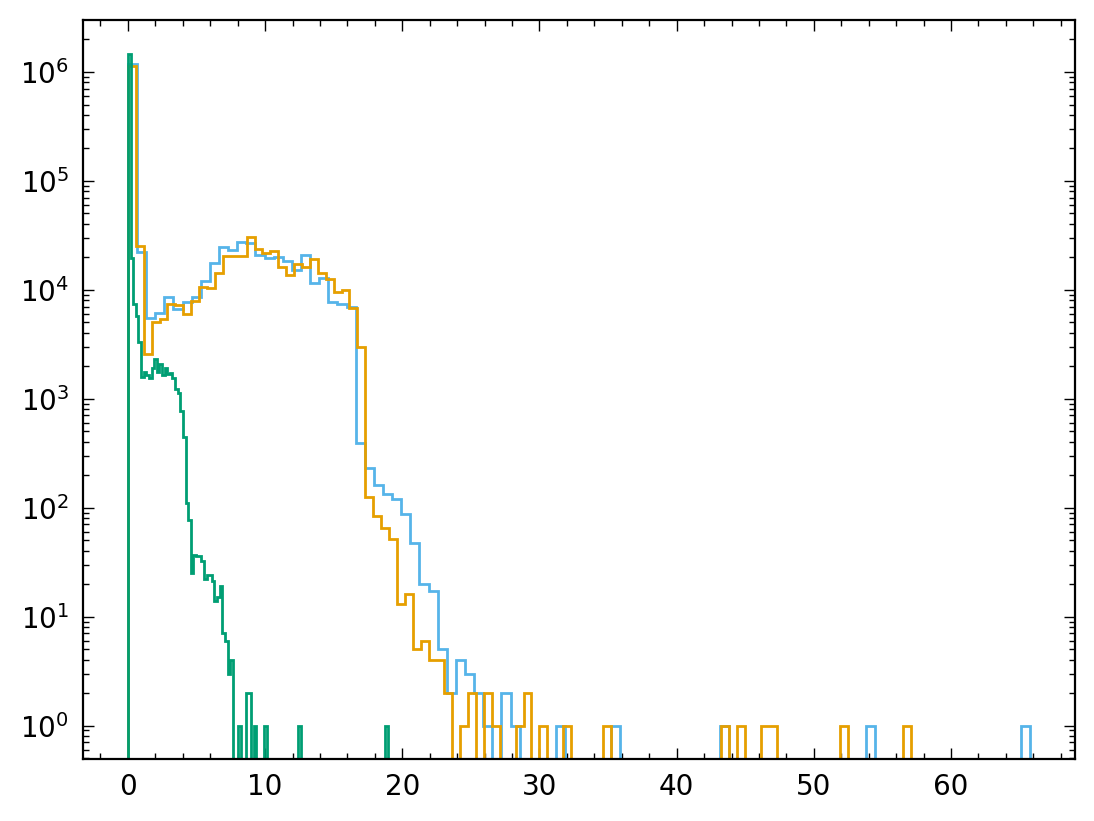

In [4]:
# Inspect distribution of observables
sel = 'peff_protection'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pH,stim_pP
0,-13.397942,2.156799,1.047152,0.812756
1,-3.349485,5.455414,1.043316,0.905653
2,0.700124,0.215982,1.193483,0.059267
3,0.717337,0.284937,1.372561,0.097381
4,0.735609,0.356626,1.502922,0.134891
...,...,...,...,...
98,2.478566,4.290195,1.596791,0.499380
99,2.569374,4.567184,1.658669,0.544472
100,2.677607,4.824983,1.677819,0.577462
101,2.813581,5.123346,1.680857,0.597226


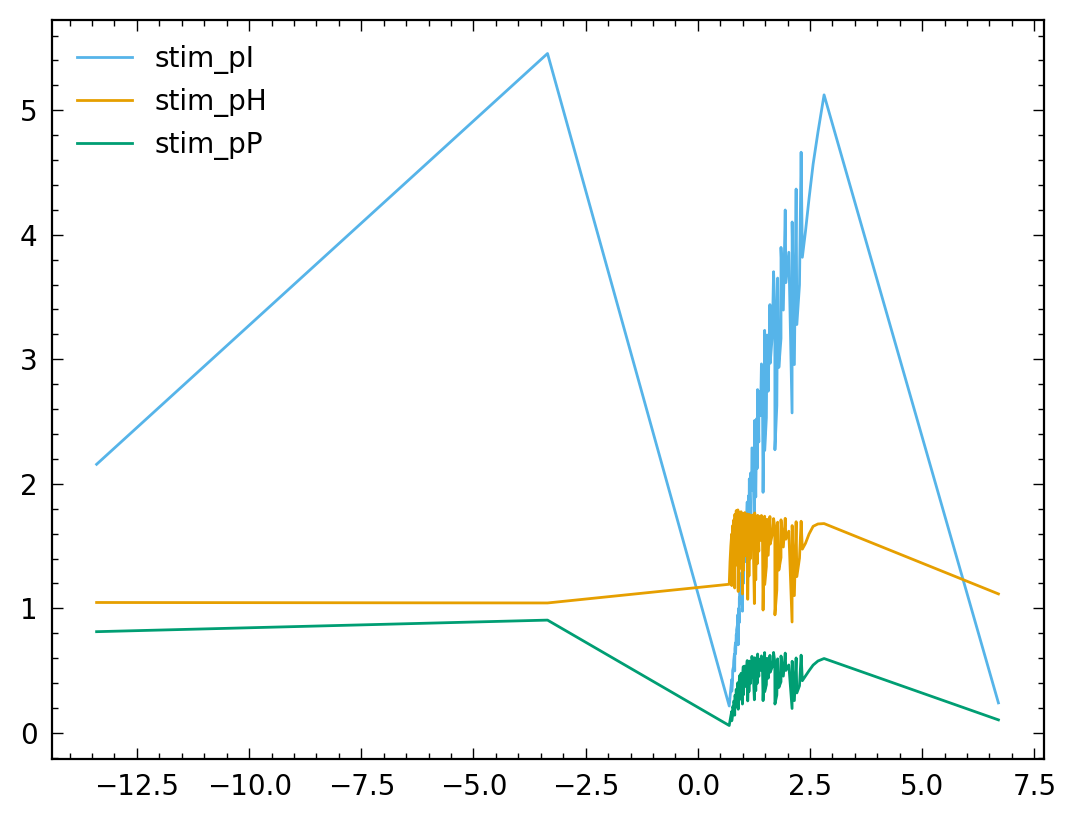

In [5]:
norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pH', 'stim_pP']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pH', 'stim_pP']], label = ['stim_pI', 'stim_pH', 'stim_pP'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 10
fevals: 14
fevals: 11
fevals: 14


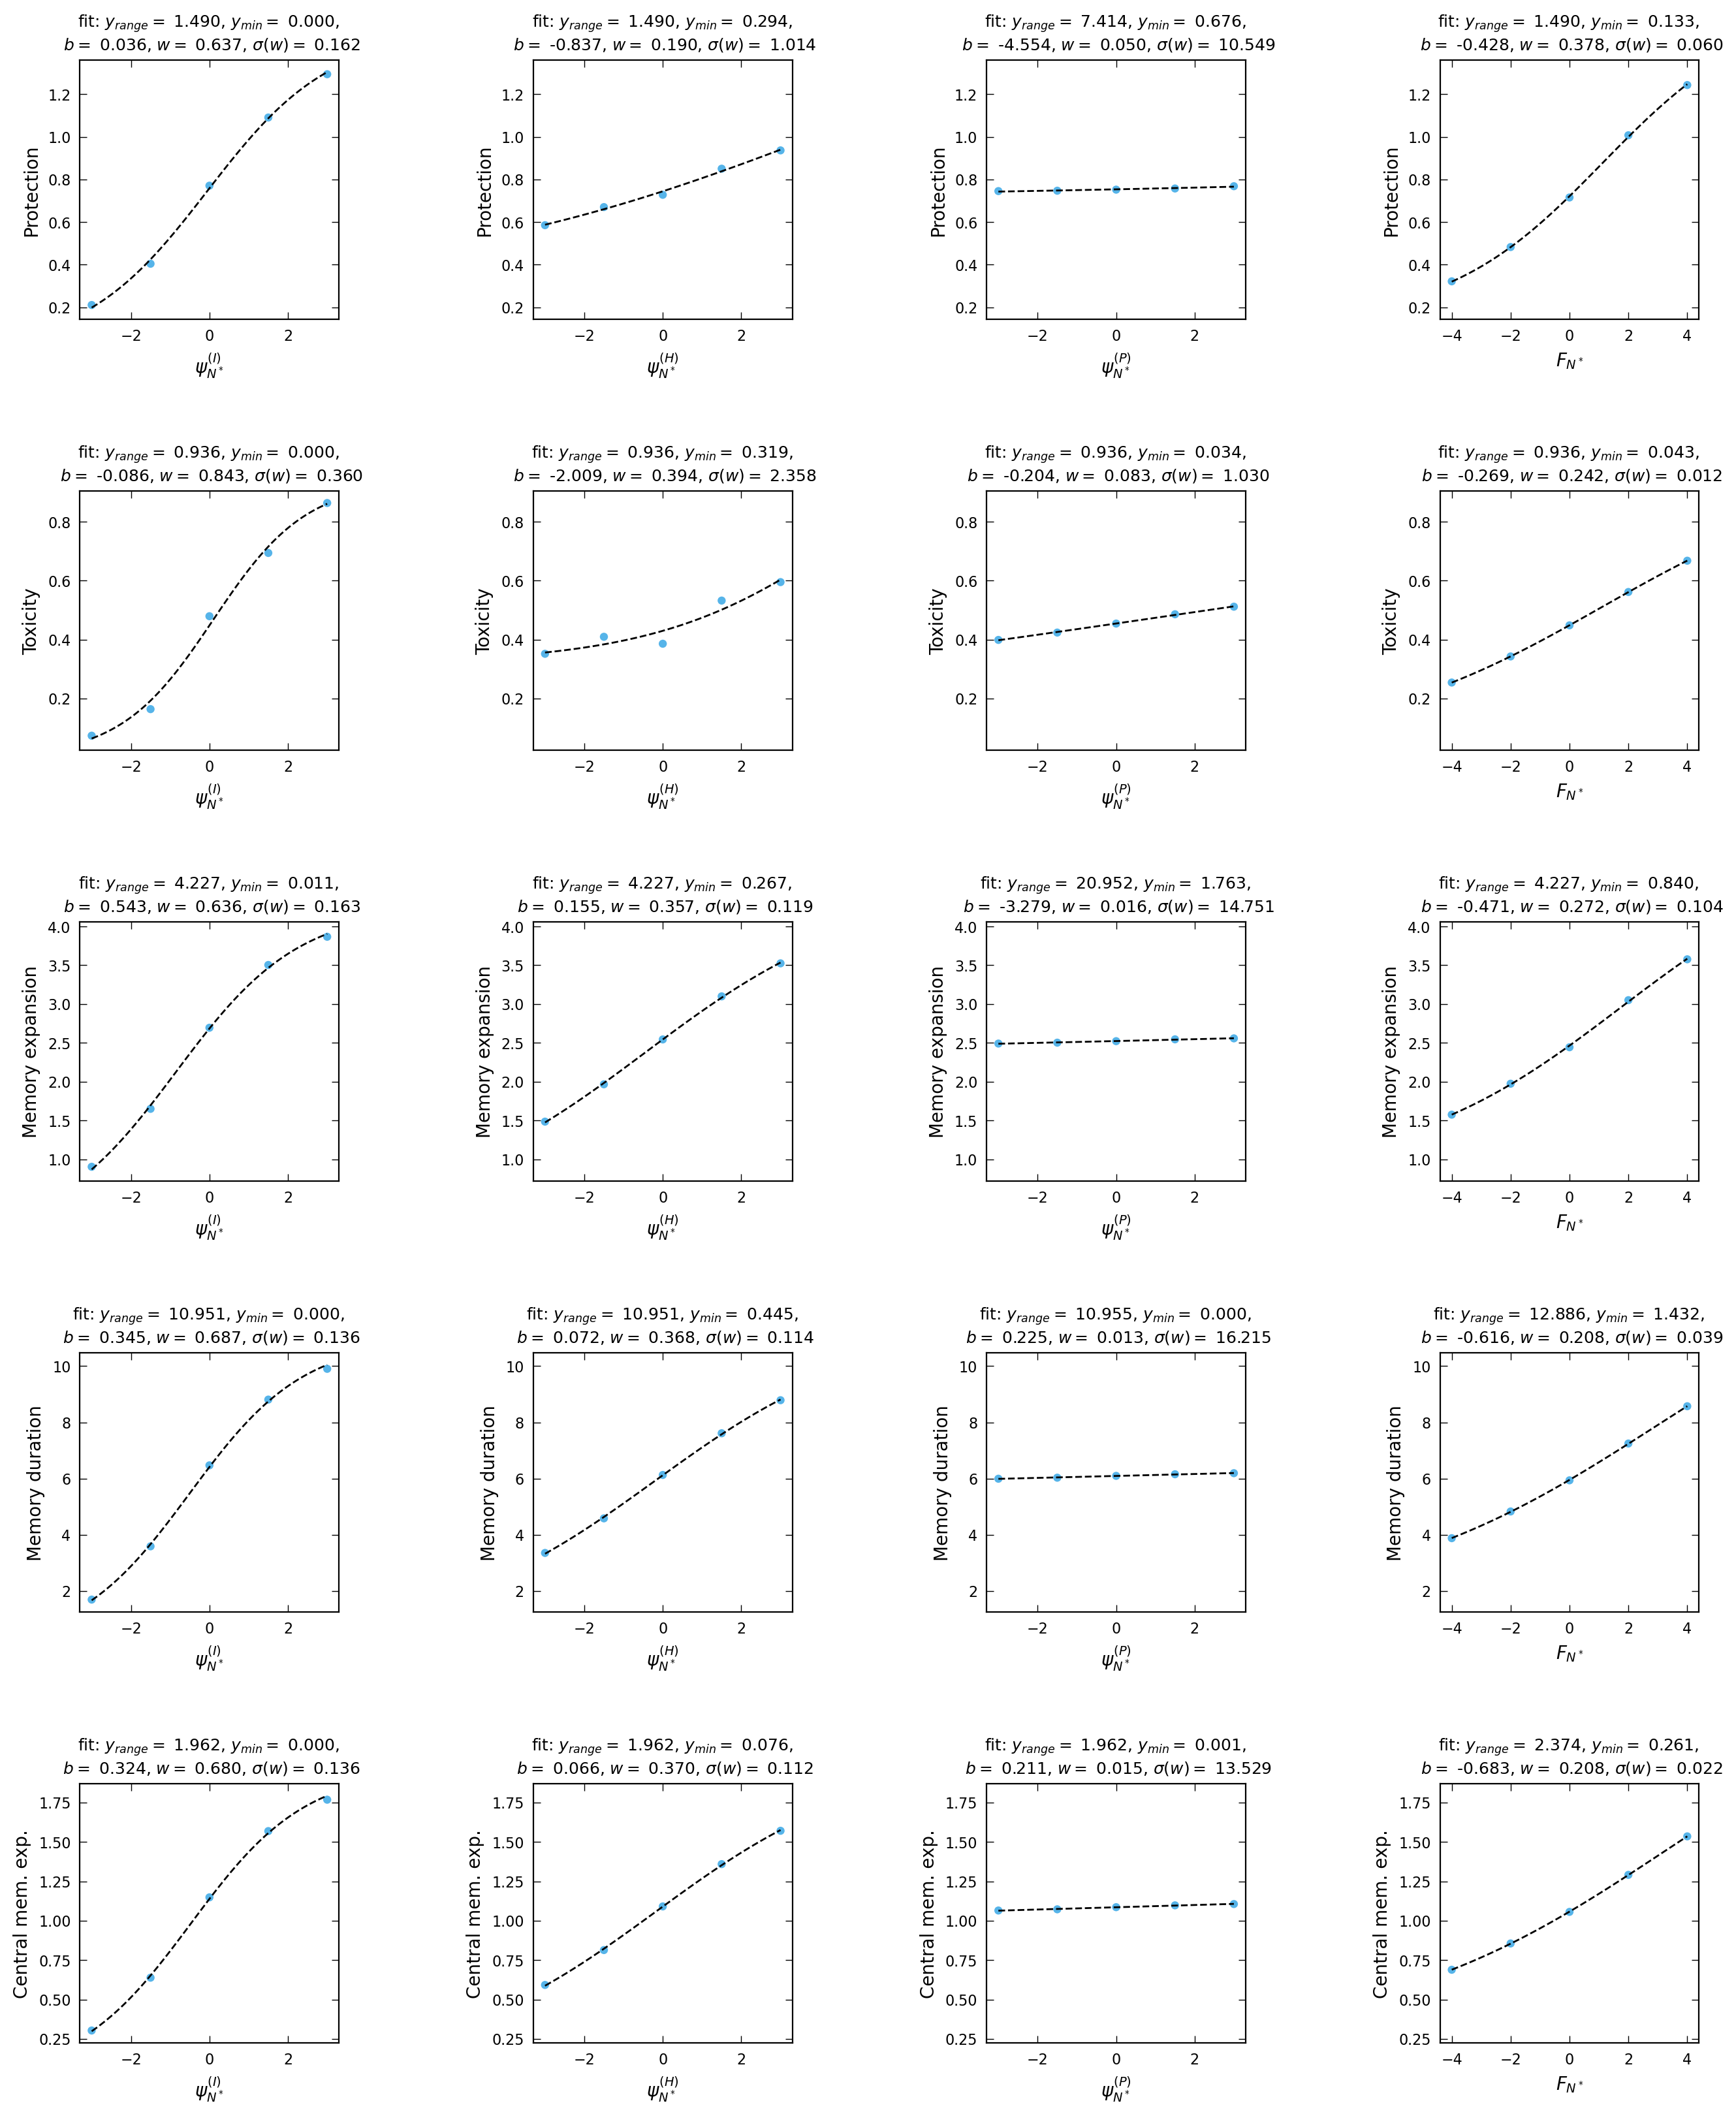

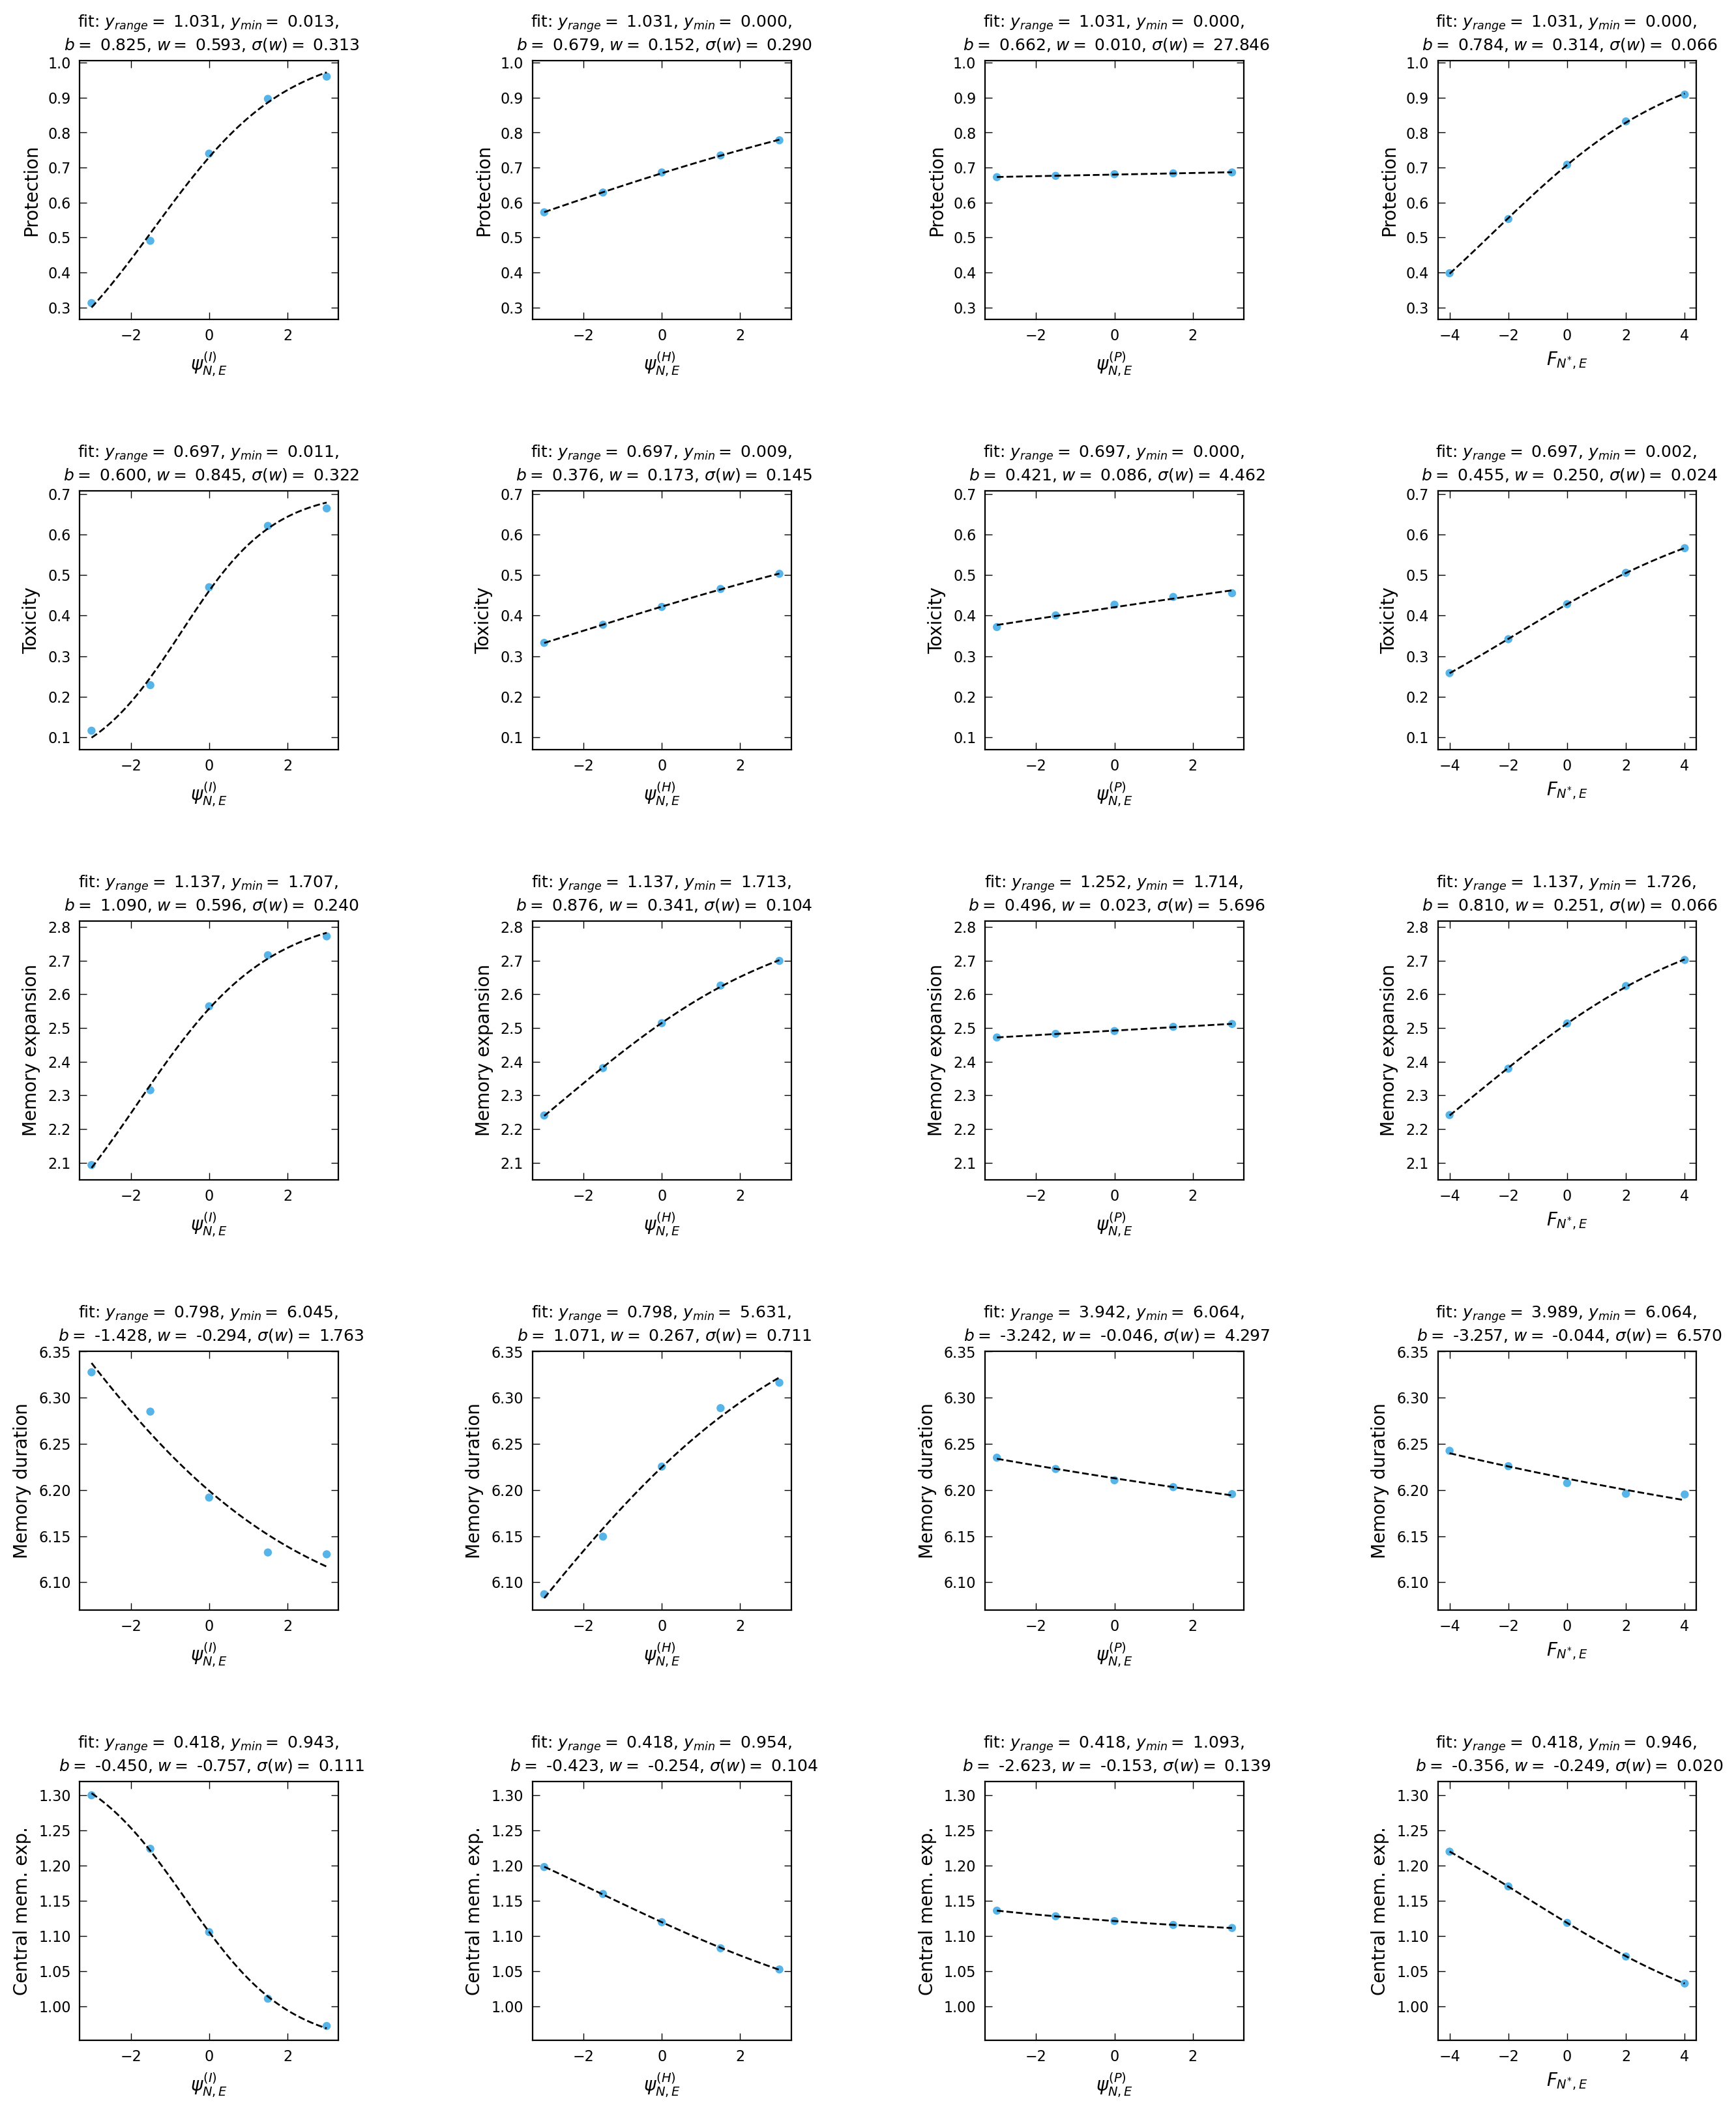

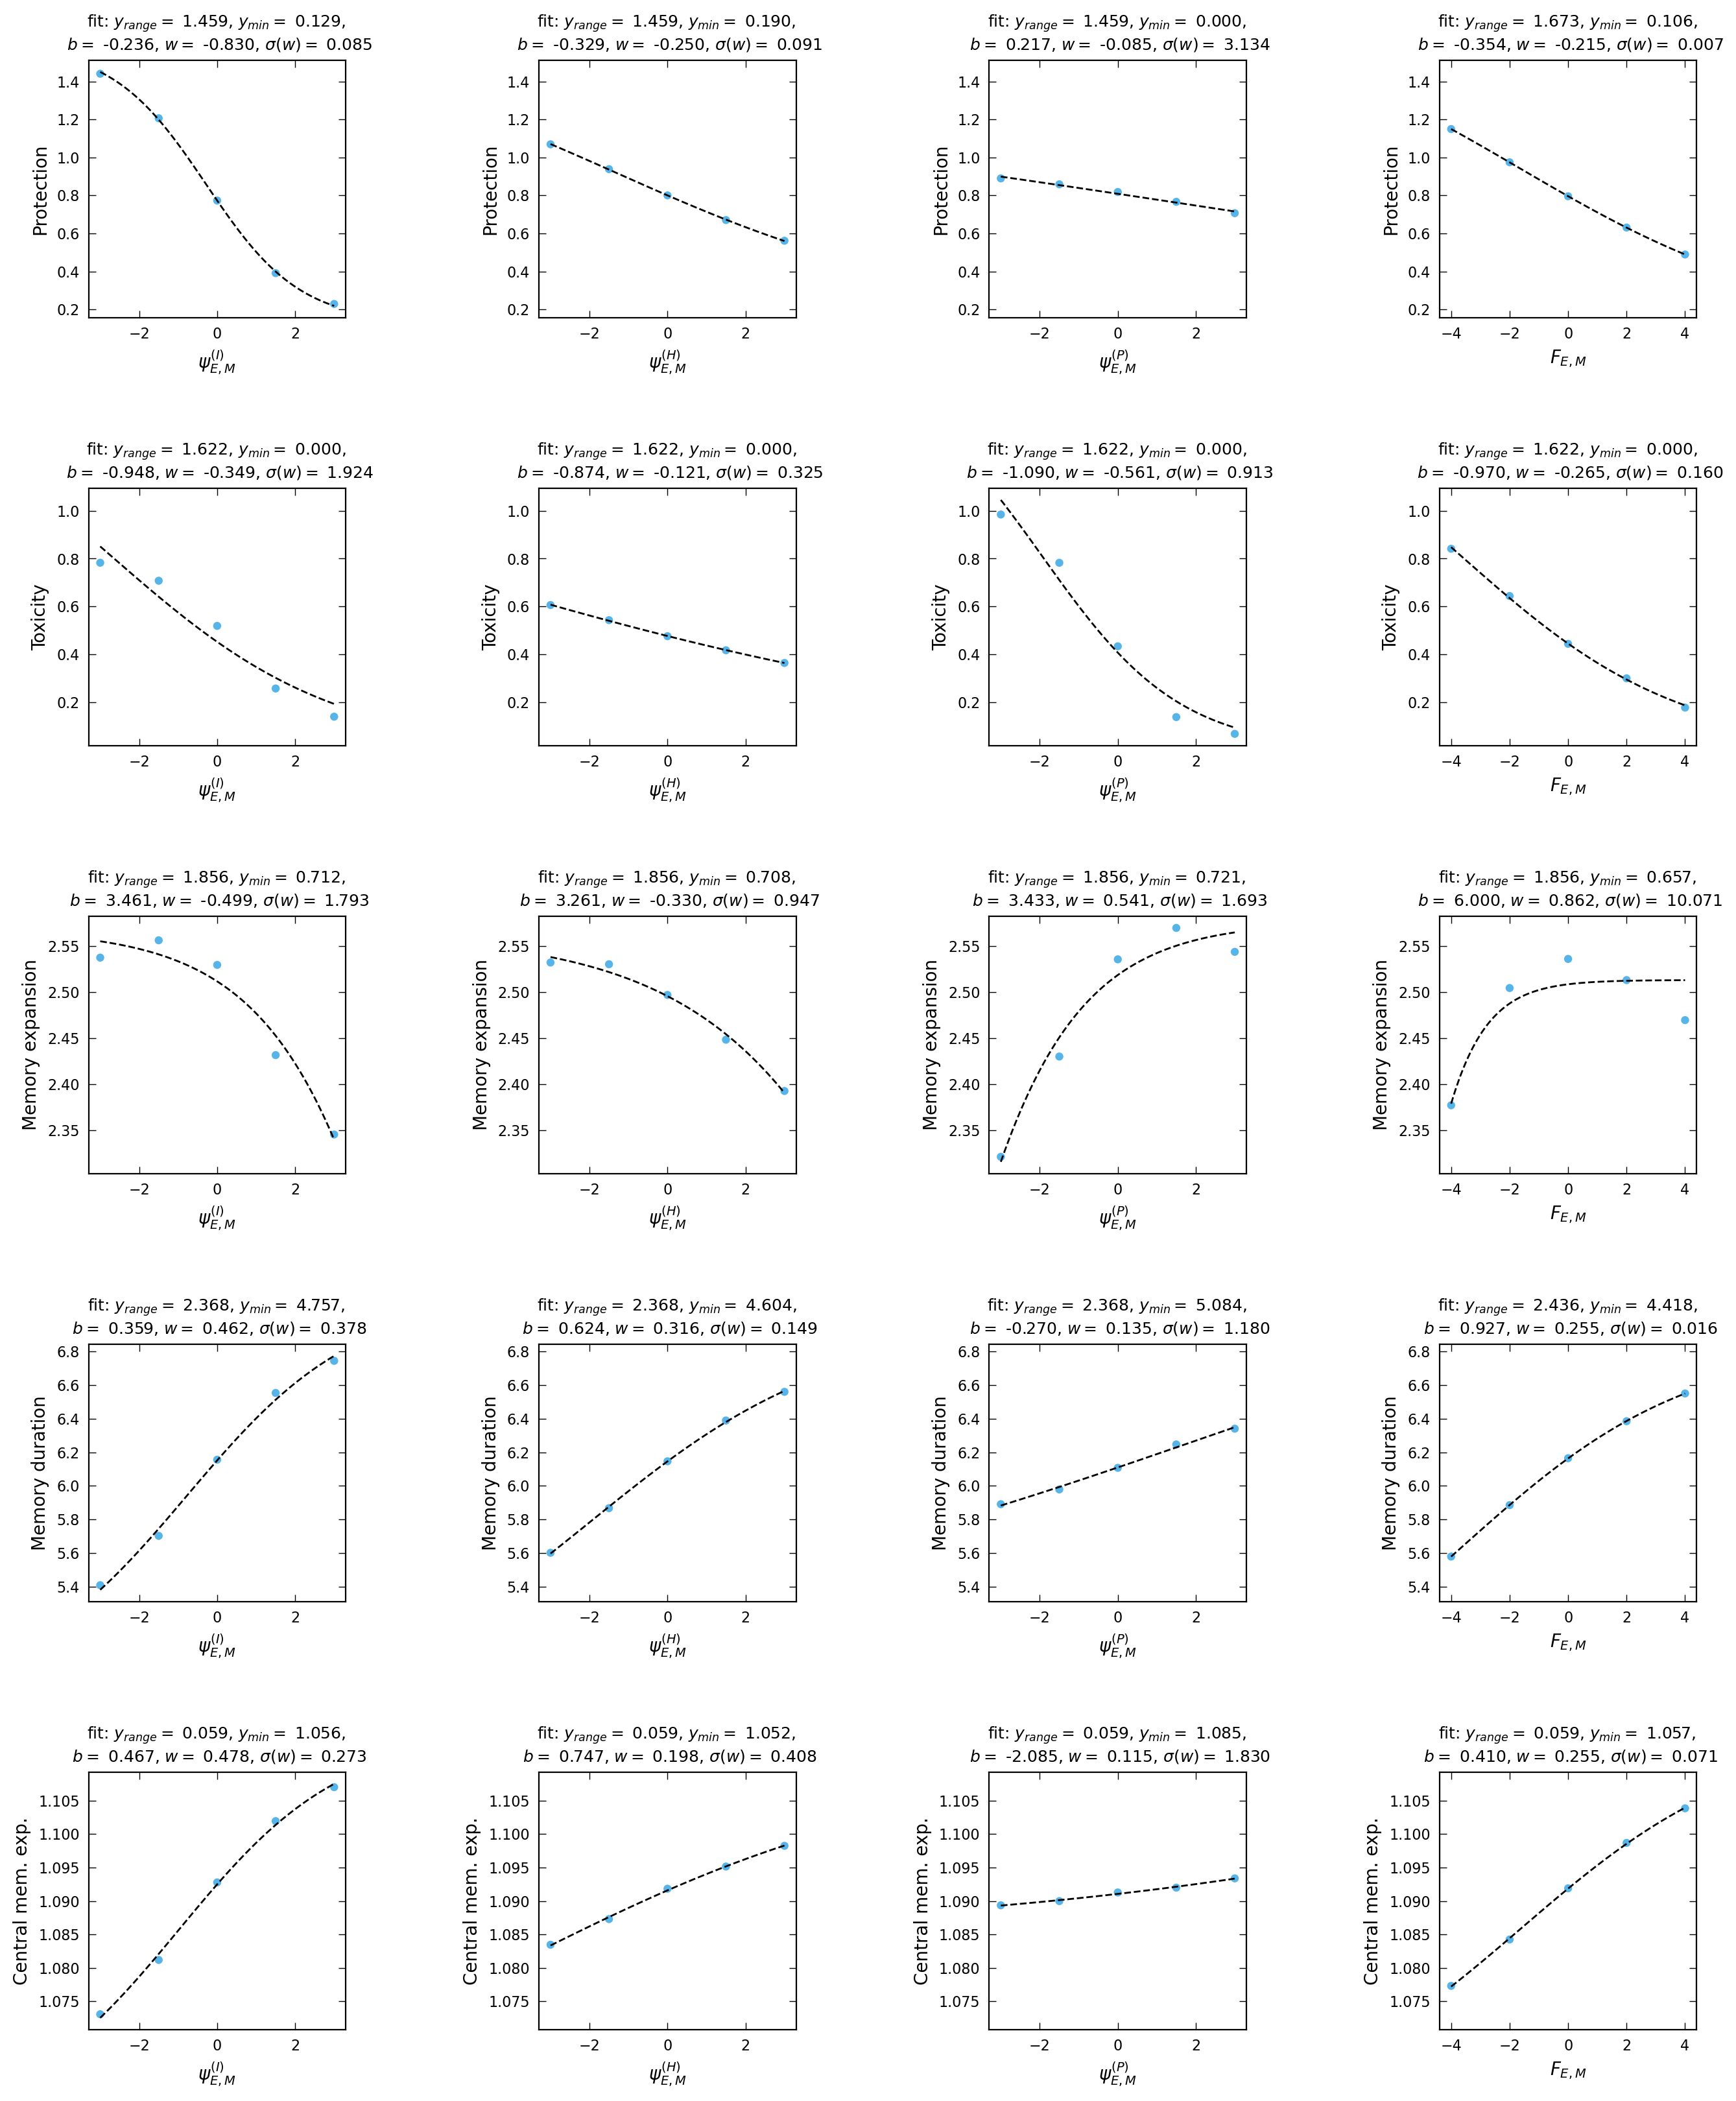

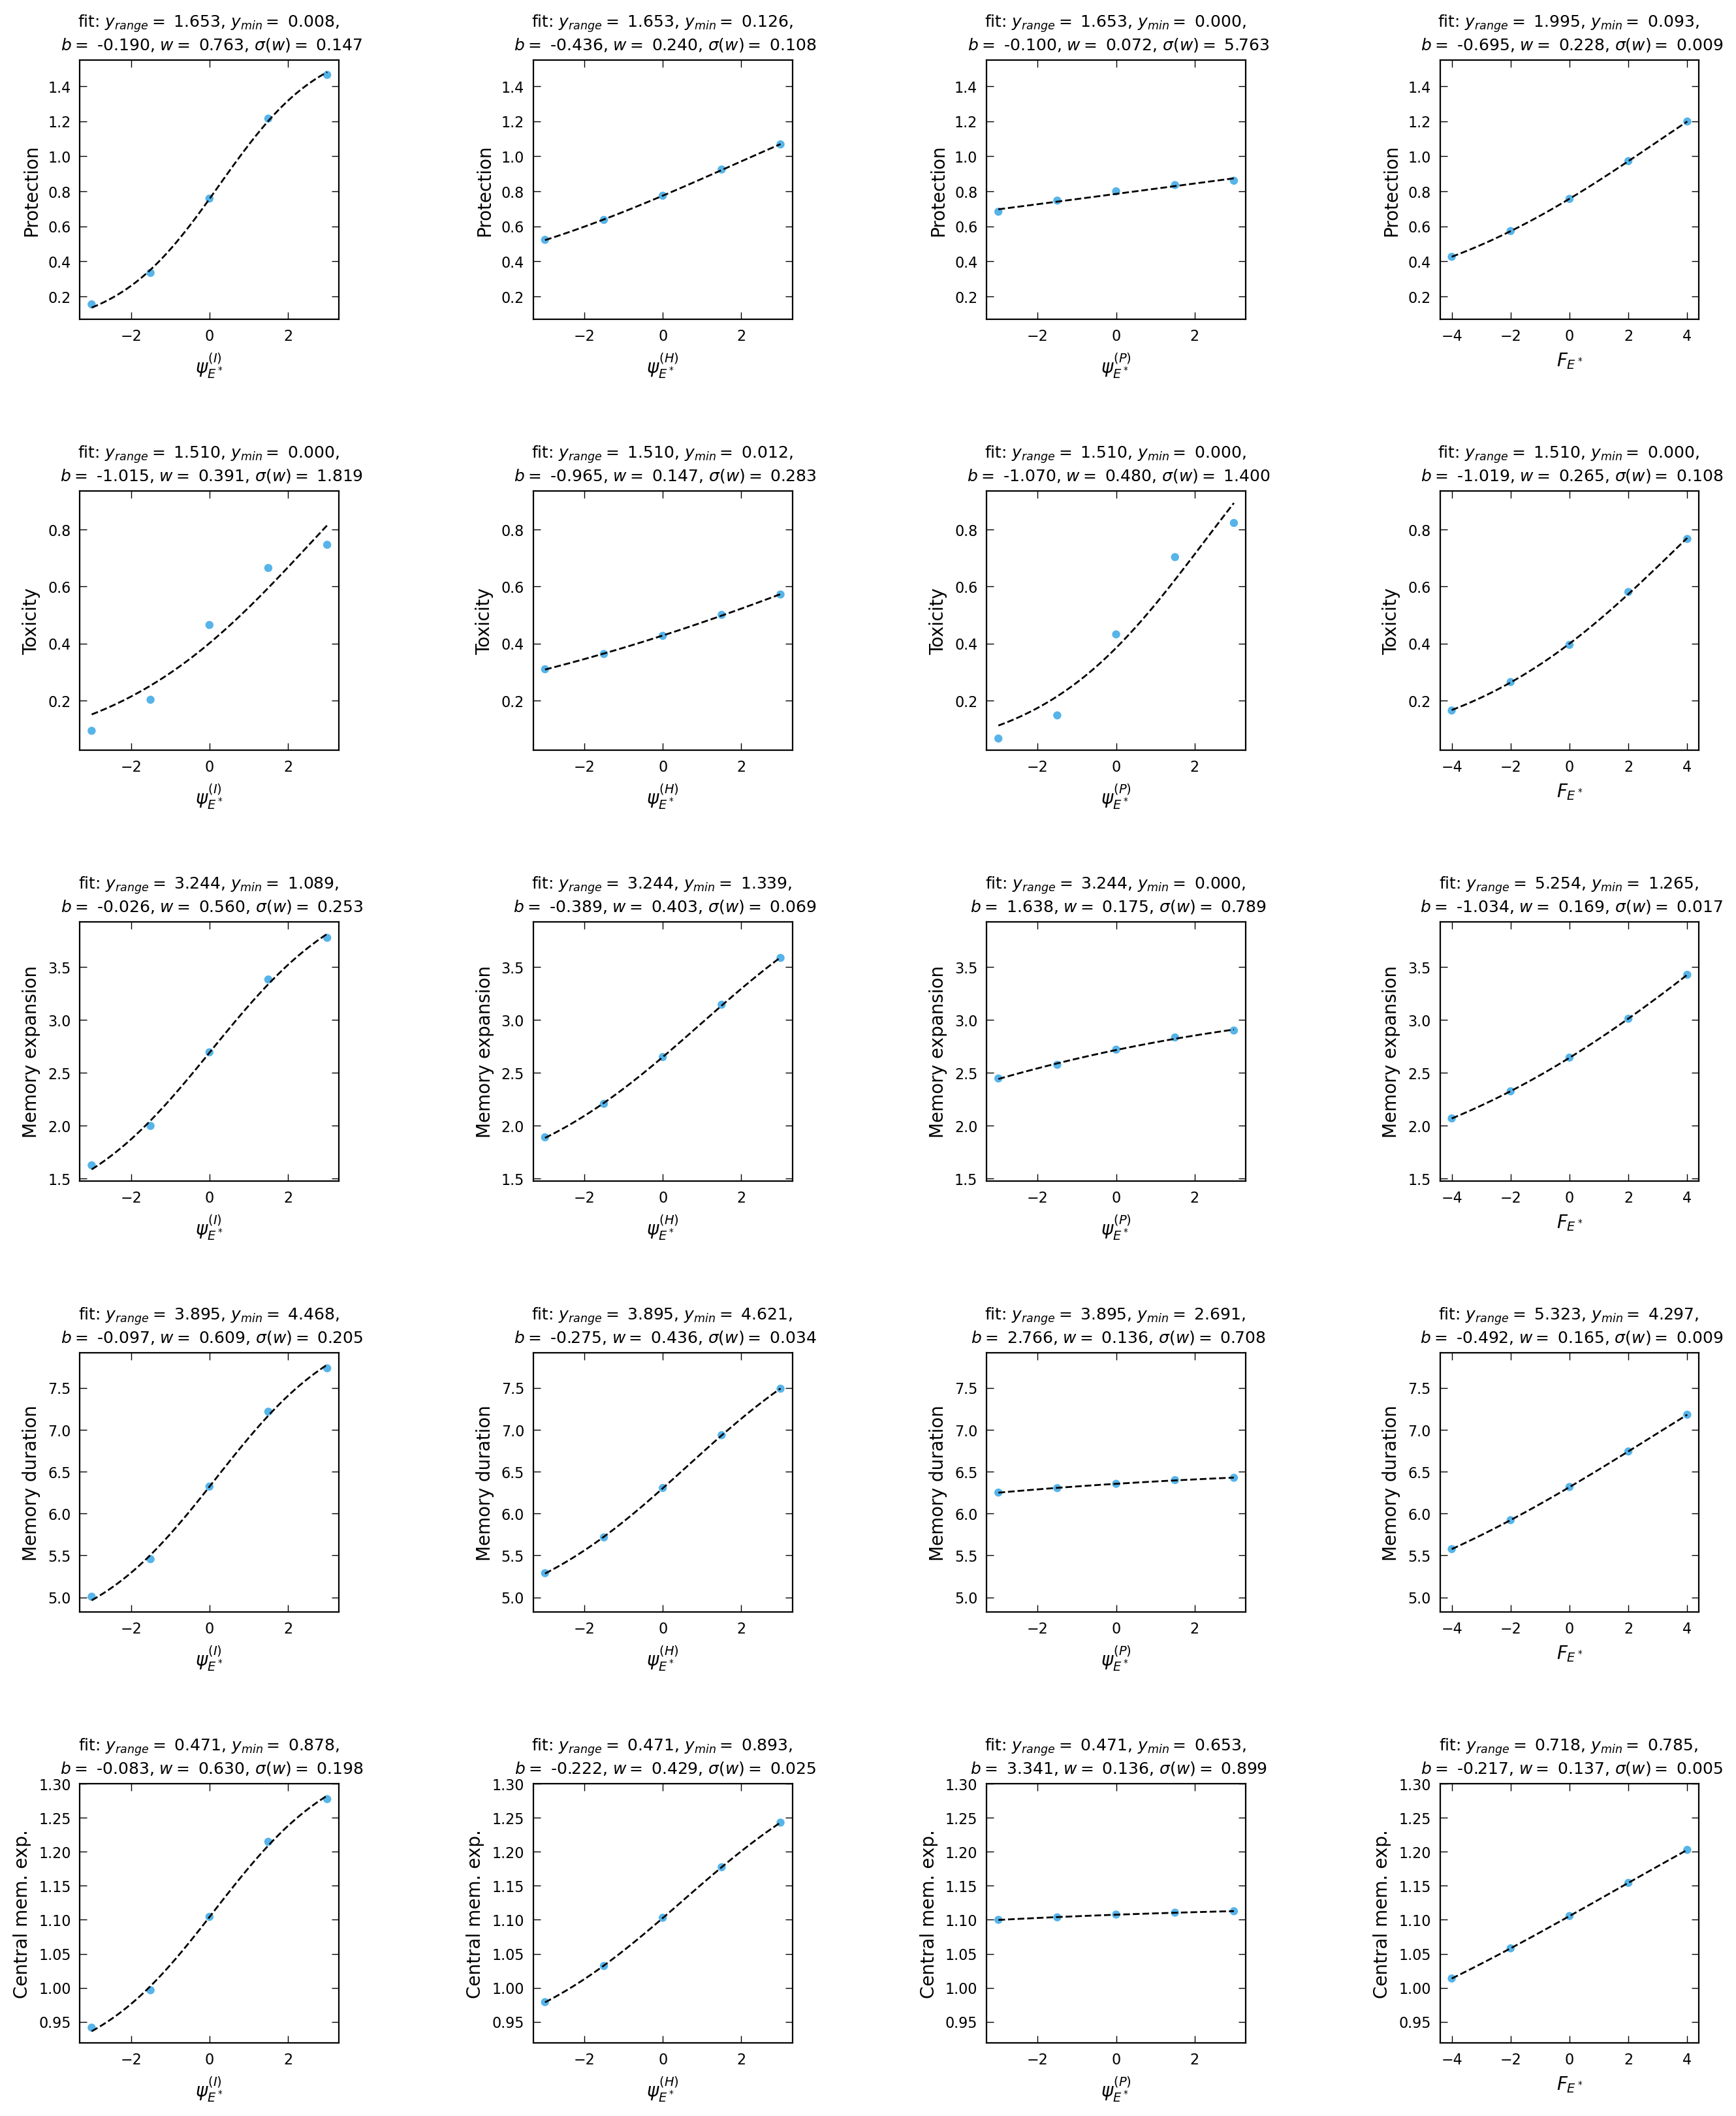

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    
    x_varname= key_var
    fig_c, axs = plt.subplots(num_categories, len(reg_choice), 
                              figsize=(len(reg_choice)*len(reg_choice), np.maximum(3.5, len(reg_choice))*num_categories), sharex='col', sharey='row')

    data = clustered_mean_df.loc[(clustered_mean_df.K_EH == K_EH)].groupby(reg_choice, as_index = False).mean()
    
    for i, var in enumerate(perf_vars):
        
        for j, p in enumerate(signal_classes):
            data_mean = data.groupby(reg_choice[j], as_index = False).mean()
            im = axs[i, j].scatter(data_mean[reg_choice[j]], data_mean[var], 
                              marker = 'o', s = 20, edgecolors = 'None')

            y_max = np.max(data[var].values)
            y_min = np.min(data[var].values)
            y_std = np.std(data[var].values)

            #if var != 'T_max_pI':
            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*psi_max, -2*psi_max], 
                                             [5*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*psi_max, 2*psi_max]),
                                   maxfev=5000,
                                   full_output = True)
  
            sigma_w = np.sqrt(np.diag(pcov))[-1]

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i, j].plot(x, sigmoid_1d(x, *popt), 'k--')

            axs[i, j].set_title('fit: $y_{range} =$ %5.3f, $y_{min} =$ %5.3f, \n $b=$ %5.3f, $w=$ %5.3f, $\sigma(w) =$ %5.3f' % tuple(popt.tolist() + [sigma_w]), fontsize = 9.0)
                
            axs[i, j].minorticks_off()
            axs[i, j].yaxis.set_tick_params(labelbottom=True)
            axs[i, j].xaxis.set_tick_params(labelbottom=True)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)
            axs[i, j].set_box_aspect(1)
            axs[i, j].set_ylabel(perf_labels[i], fontsize = 10)
            axs[i, j].set_xlabel(reg_label[module_index*len(reg_choice) + j ], fontsize = 10)

        if i == 0:
            print("fevals:", infodict['nfev'])
    
    fig_c.subplots_adjust(wspace=.75, hspace=0.5)
    plt.savefig('_figs/'+comment+'-'+reg_choice_label+'-mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")
    del data

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 108
variables = reg

def model(input, fit = "linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, 0.0] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([(y_max - y_min)/2, 0.0 if y_min > 0.0 else y_min] + len(variables)*[-2.5*F0_max] + num_modules*[-3.0*F0_max], 
                                     [2.0*(y_max - y_min) if (y_max - y_min) > 0 else y_std + 0.1, np.maximum(y_min, y_std + 0.01)] + len(variables)*[2.5*F0_max] + num_modules*[3.0*F0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pH'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pP'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_range', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pH', 'stim_pP'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [20]:
# View result
perf = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,0.855833,2.065855e-16,0.317803,0.181721,0.083272,2.269329,0.173025,0.000088,0.105236,0.947386,-0.248176,0.005475,-0.261154,-1.751001,0.354413,0.019793,0.296171,2.867122,-4.484630,1.095908,-3.196867,-12.000000,0.002262,0.000007,0.001435,0.001352,0.001308,0.010611,0.001413,0.001390,0.001399,0.001408,0.001355,0.001277,0.001362,0.003697,0.001052,0.000470,0.000941,0.019189,0.020720,0.002851,0.006848,0.076444,0.01,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.003804,0.734166,0.0,0.000000e+00,1.0,0.003914,0.027066,0.000000,0.180540,0.060883,0.003920,NaN
6,0.071449,2.242205e-18,0.170167,0.172845,0.032499,1.834153,0.097207,-0.030118,-0.007339,0.943392,-0.108968,0.029263,-0.039179,-1.703823,0.329224,0.029800,0.092899,2.923117,-4.512073,0.967358,-3.145100,-12.000000,0.000634,0.000001,0.002473,0.002476,0.002367,0.015375,0.002769,0.002755,0.002754,0.002835,0.002380,0.002357,0.002358,0.007924,0.002879,0.001030,0.001305,0.047620,0.028354,0.005504,0.014677,0.189544,0.01,100000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.000290,0.062561,0.0,0.000000e+00,1.0,0.000653,0.002264,0.000000,0.094339,0.060883,0.000276,NaN
11,1.253823,4.702258e-13,0.320792,0.642202,0.104815,1.765218,0.171540,-0.004152,0.143607,0.953884,-0.242483,-0.003559,-0.334289,-1.748937,0.320515,0.124958,0.335094,2.849846,-3.532946,1.098508,-3.225832,-12.000000,0.003789,0.000012,0.001852,0.002369,0.001626,0.004703,0.001722,0.001695,0.001714,0.001709,0.001667,0.001569,0.001739,0.004424,0.001121,0.000677,0.001153,0.022054,0.008770,0.003438,0.008182,0.087842,0.05,50000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.005206,1.064700,0.0,0.000000e+00,1.0,0.006505,0.037507,0.000000,0.173276,0.267120,0.005976,NaN
16,0.139121,3.001167e-40,0.128143,0.497810,0.010949,1.282326,0.099236,-0.020866,0.029078,0.929396,-0.124280,-0.005877,-0.066111,-1.732280,0.309081,0.178243,0.105849,2.897533,-3.603309,0.950416,-3.206461,-12.000000,0.000940,0.000002,0.001614,0.002324,0.001550,0.004165,0.002431,0.002418,0.002419,0.002454,0.002131,0.002101,0.002110,0.007310,0.002050,0.001427,0.001090,0.039858,0.007039,0.004806,0.013603,0.158774,0.05,100000000.0,0.000000e+00,50000.0,300.000000,10000000.0,0.0,0.000466,0.105193,0.0,0.000000e+00,1.0,0.000922,0.003606,0.000000,0.090387,0.267120,0.000486,NaN
21,6.359645,9.636853e-39,3.540452,0.392172,0.507809,1.720068,2.437958,0.254883,0.342898,1.167437,-2.156574,-0.349435,-1.397198,-1.455472,3.886021,0.585617,1.868739,2.101628,0.640444,2.272278,-2.763312,-2.938368,0.008502,0.000729,0.020531,0.006150,0.006413,0.009481,0.013170,0.005468,0.005617,0.005773,0.010280,0.003811,0.007189,0.006493,0.018692,0.005695,0.010138,0.009228,0.005529,0.013202,0.011652,0.016475,0.25,10000.0,1.500000e-07,50000.0,300.000000,10000000.0,1000.0,0.272430,7.412860,0.0,7.638841e-04,1.0,0.366871,1.028422,5.383736,5.123346,1.680857,0.597226,2.813581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,0.210489,2.075055e-42,0.618371,2.355552,0.159769,2.104677,0.271866,1.041061,0.140840,0.946822,-0.504882,-1.935436,-0.423725,-1.695905,0.624906,2.307445,0.498522,2.075207,-0.036693,1.257601,-3.0

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for protection, toxicity and memory are above 0.80.

Text(0, 0.5, 'Counts')

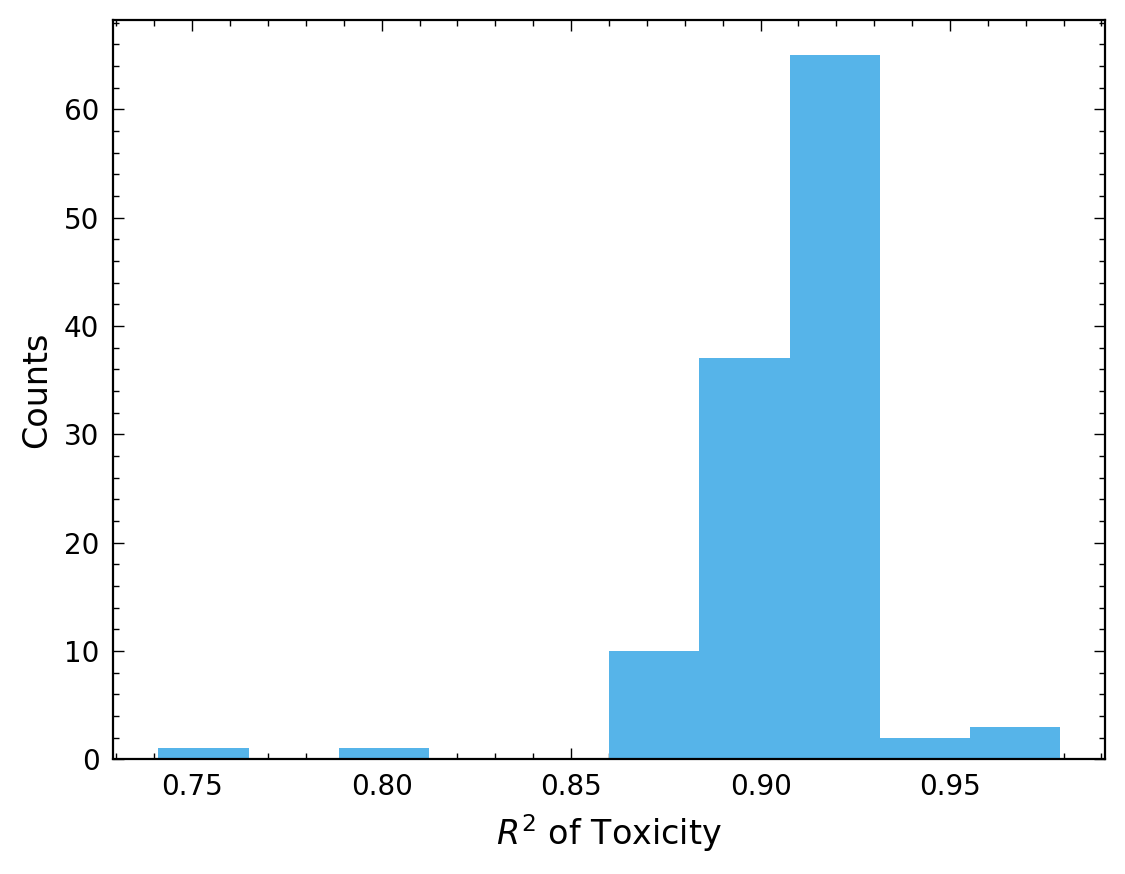

In [21]:
model_r_sq = 1 - impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].rmse**2/impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_std**2
plt.hist(model_r_sq);
plt.xlabel(r"$R^2$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0, 0.5, 'Counts')

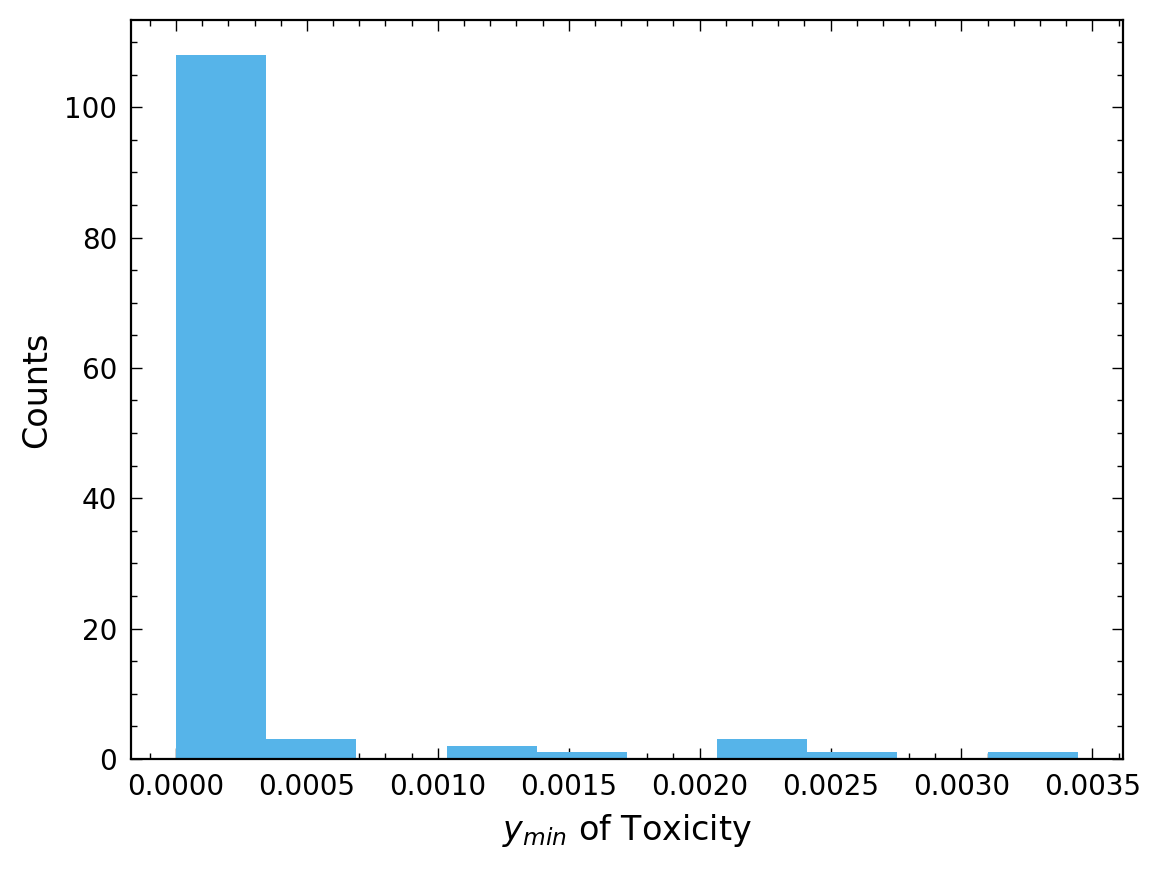

In [22]:
plt.hist(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.K_EH == K_EH)].y_min);
plt.xlabel(r"$y_{min}$ of "+perf_labels[perf])
plt.ylabel("Counts")

Text(0.5, 0, 'Variable')

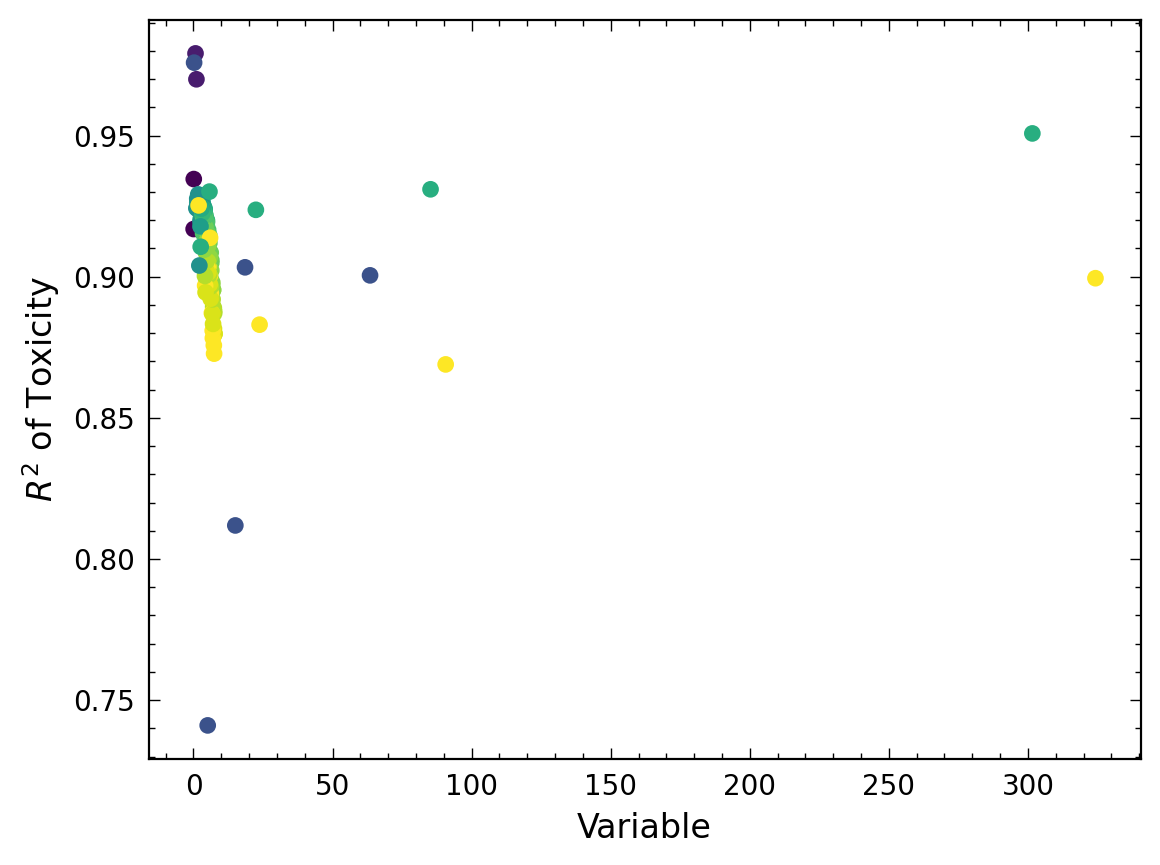

In [23]:
plt.scatter(impact_data.loc[(impact_data.perf_index == perf)].max_perf, model_r_sq, 
            c = 1/impact_data.loc[(impact_data.perf_index == perf)].K_IE, norm=mpl.colors.LogNorm());
plt.ylabel(r"$R^2$ of "+perf_labels[perf])
plt.xlabel("Variable")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for protection/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high protection/toxicity in this module.

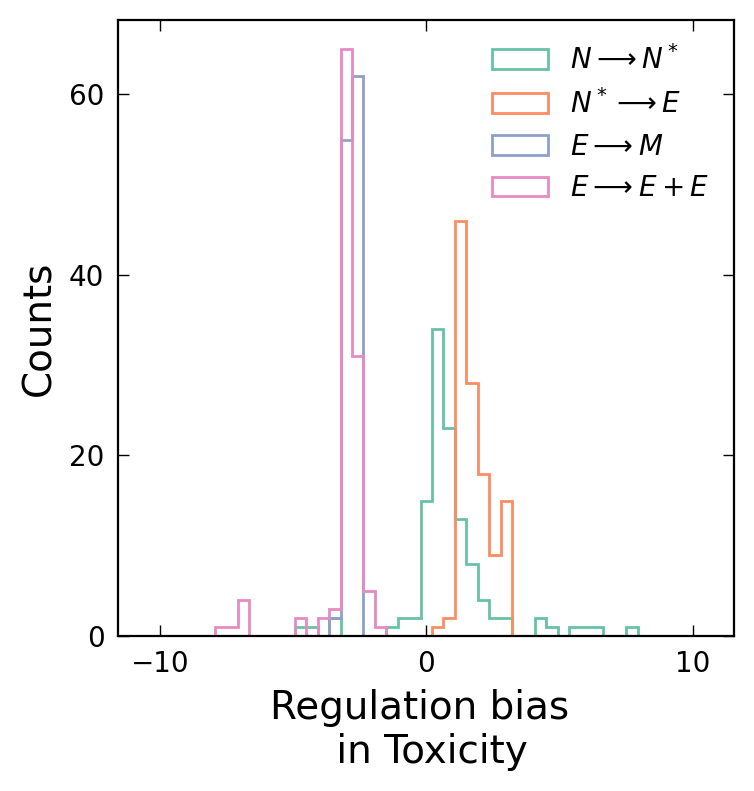

In [24]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-3.5*psi_max, 3.5*psi_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

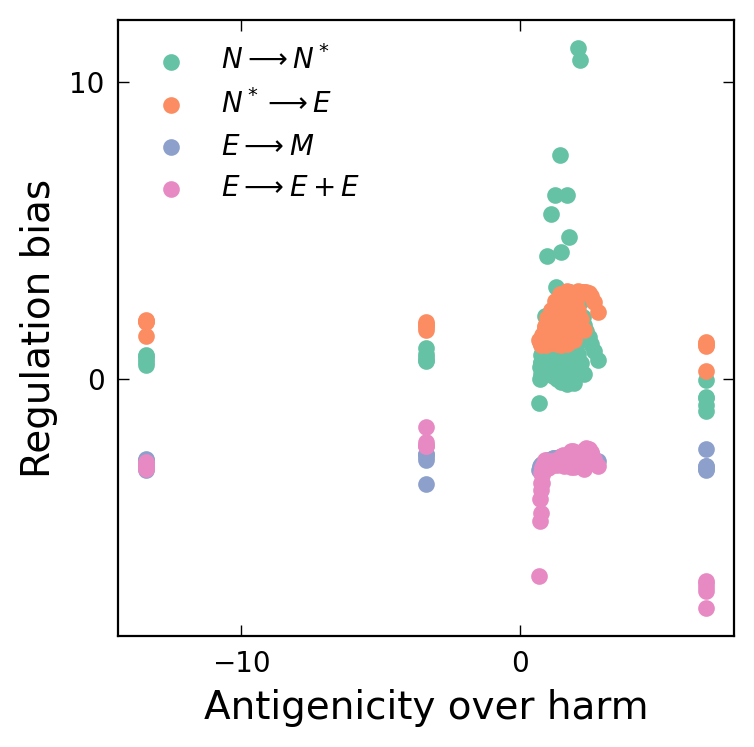

In [25]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]
    axs.scatter(data['antigenicity_over_harm'], data['intercept_'+r], label = module_labels[i], c = cmap_colors[i])

axs.legend(fontsize = 10, ncol = 1)

axs.set_ylabel("Regulation bias", fontsize = 14)
axs.set_xlabel("Antigenicity over harm", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

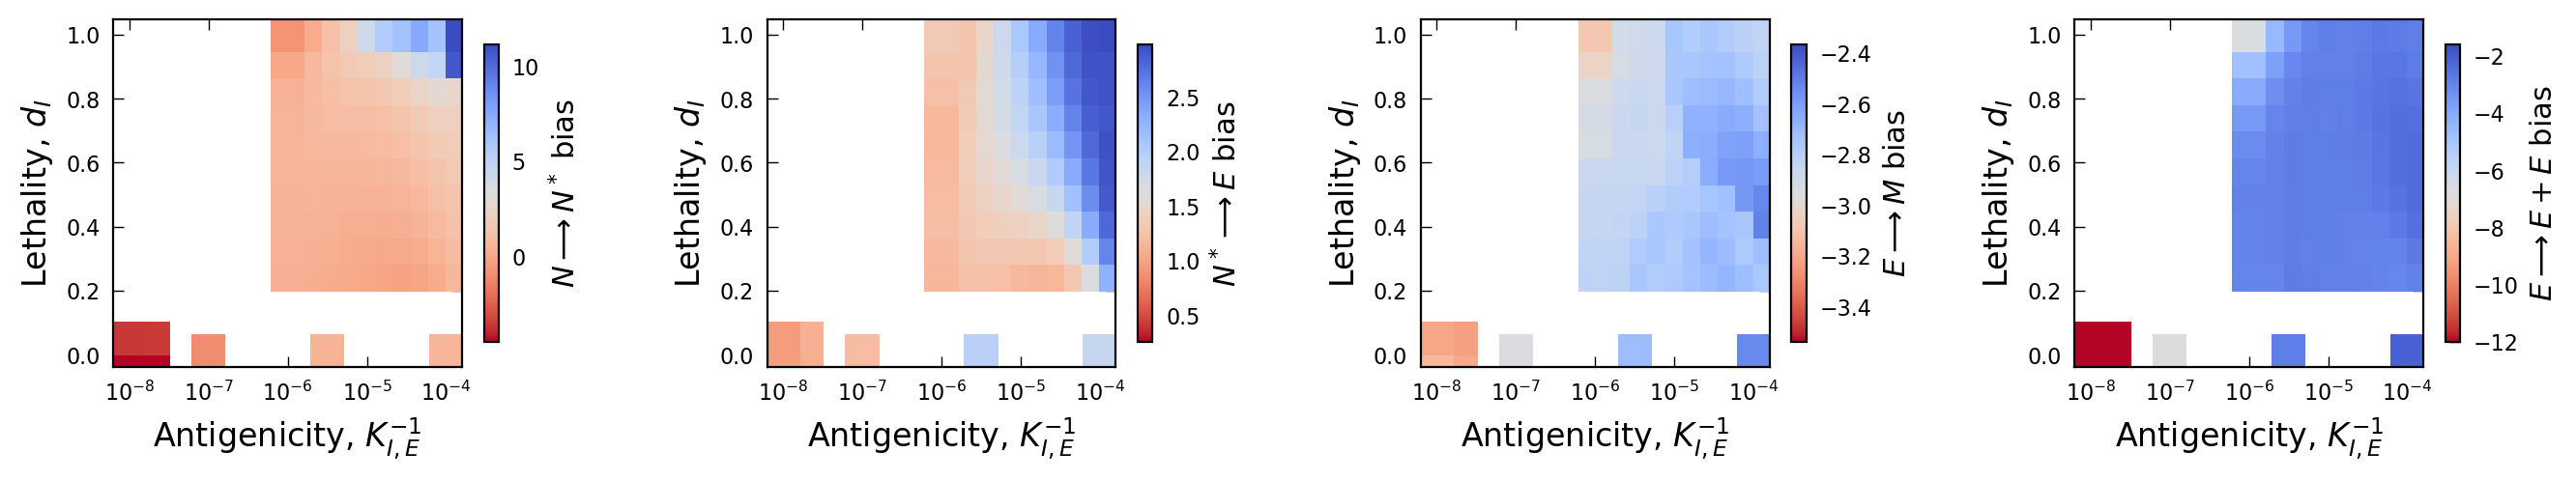

In [26]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$K_{I,E}^{-1}$", "Lethality, "+r"$d_{I}$"]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(1/data[x_varname] if x_varname == 'K_IE' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_IE' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_IE':
        axs[i].semilogx()
    if y_varname == 'K_IE':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate 

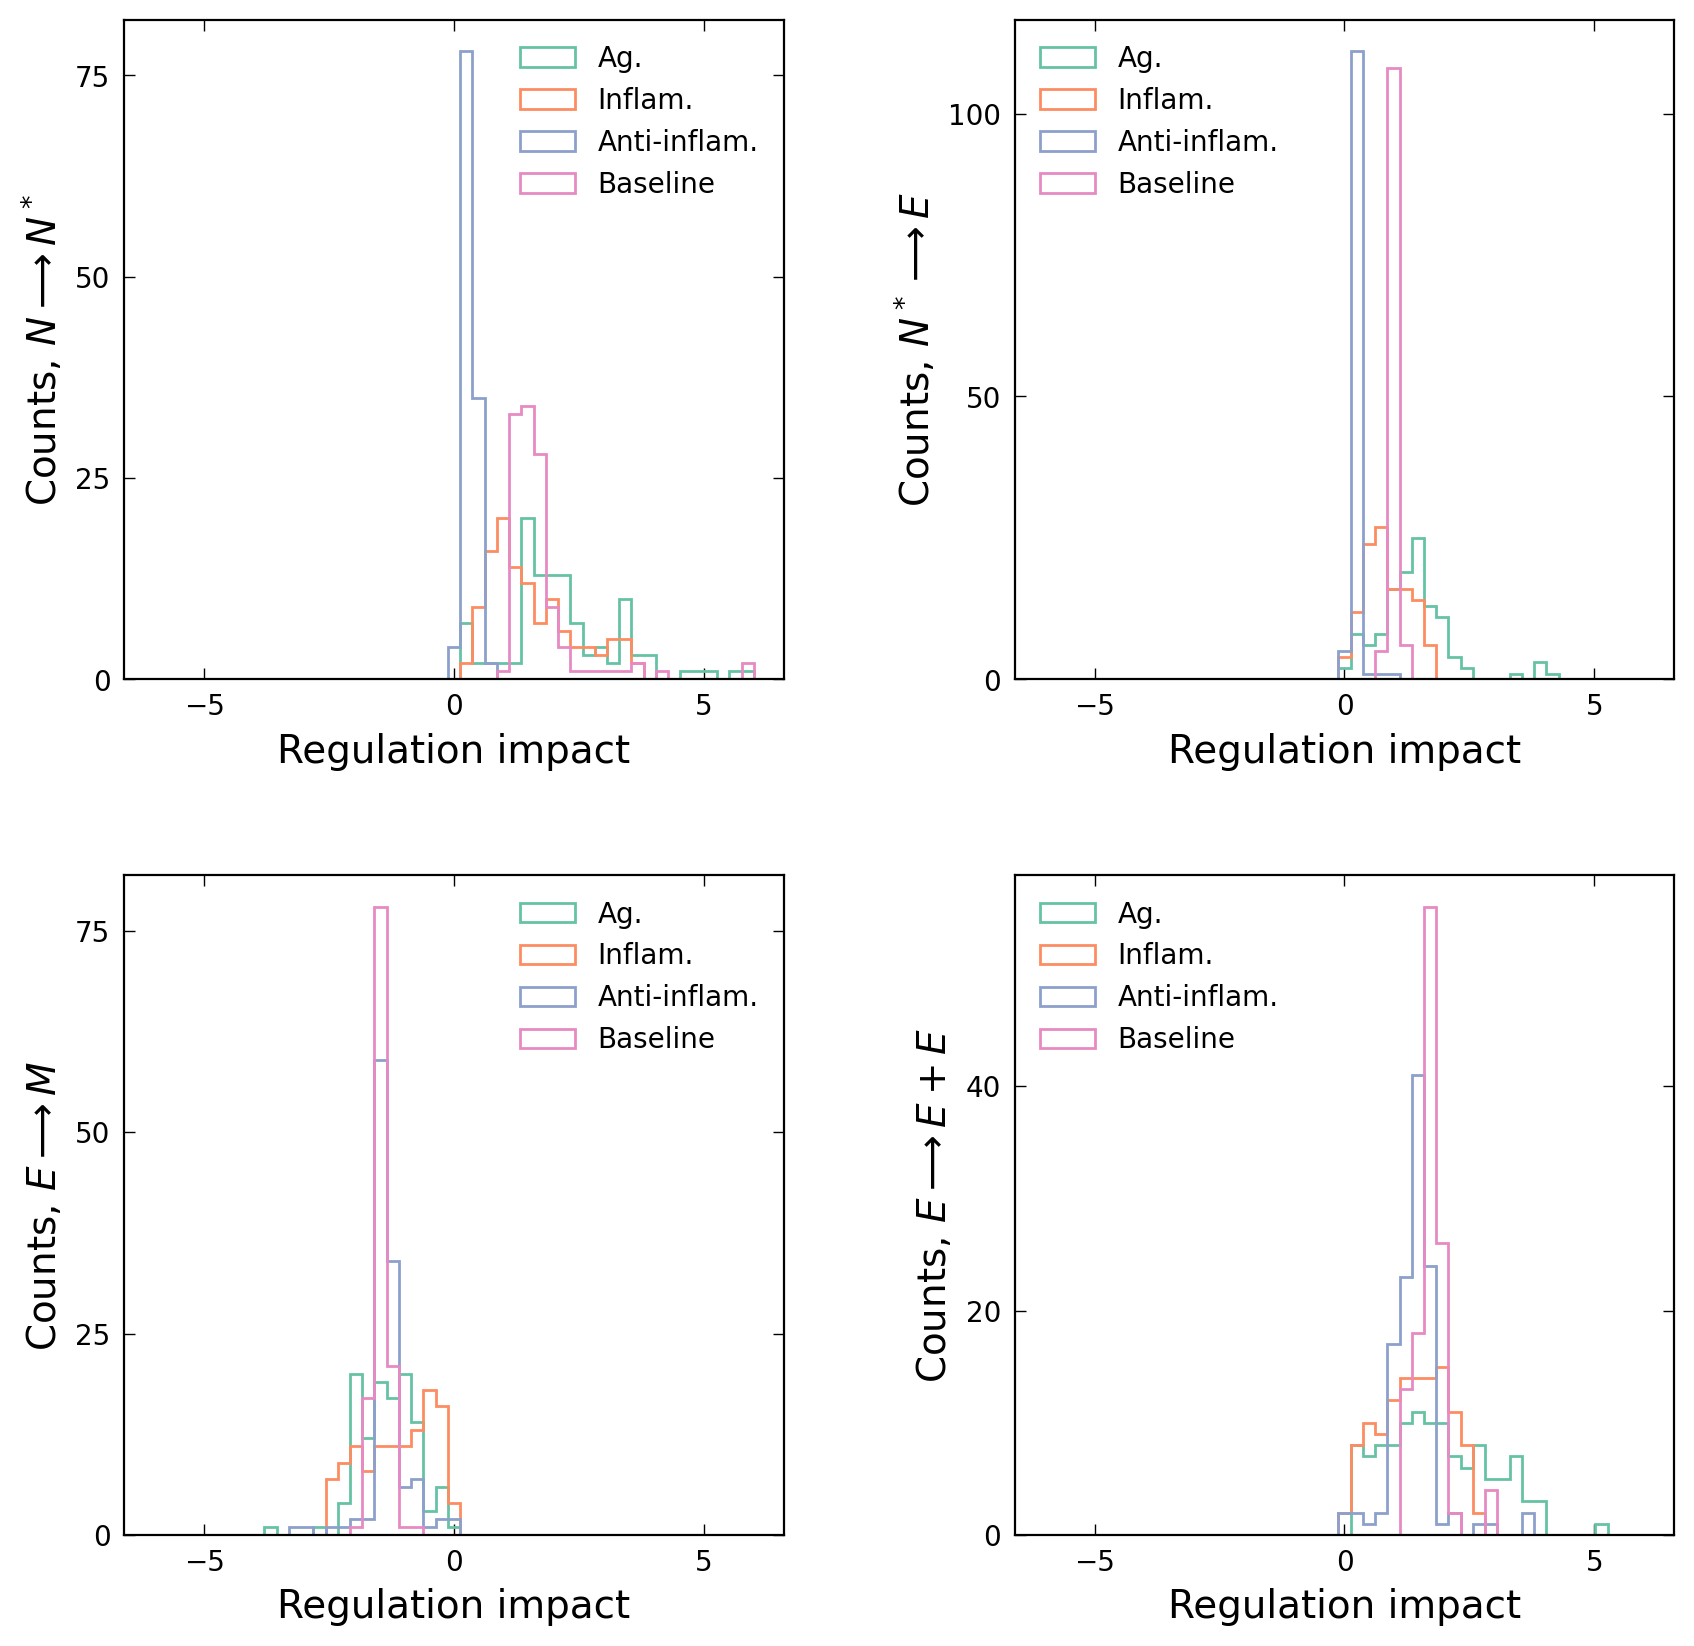

In [27]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf)*(impact_data['K_EH'] == K_EH)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-2.0*psi_max, 2.0*psi_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [28]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == 0.0)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
1,0.855833,2.065855e-16,0.317803,0.181721,0.083272,2.269329,0.173025,0.000088,0.105236,0.947386,-0.248176,0.005475,-0.261154,-1.751001,0.354413,0.019793,0.296171,2.867122,-4.484630,1.095908,-3.196867,-12.0,0.002262,0.000007,0.001435,0.001352,0.001308,0.010611,0.001413,0.001390,0.001399,0.001408,0.001355,0.001277,0.001362,0.003697,0.001052,0.000470,0.000941,0.019189,0.020720,0.002851,0.006848,0.076444,0.01,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.003804,0.734166,0.0,0.0,1.0,0.003914,0.027066,0.0,0.180540,0.060883,0.003920,NaN
6,0.071449,2.242205e-18,0.170167,0.172845,0.032499,1.834153,0.097207,-0.030118,-0.007339,0.943392,-0.108968,0.029263,-0.039179,-1.703823,0.329224,0.029800,0.092899,2.923117,-4.512073,0.967358,-3.145100,-12.0,0.000634,0.000001,0.002473,0.002476,0.002367,0.015375,0.002769,0.002755,0.002754,0.002835,0.002380,0.002357,0.002358,0.007924,0.002879,0.001030,0.001305,0.047620,0.028354,0.005504,0.014677,0.189544,0.01,100000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.000290,0.062561,0.0,0.0,1.0,0.000653,0.002264,0.0,0.094339,0.060883,0.000276,NaN
11,1.253823,4.702258e-13,0.320792,0.642202,0.104815,1.765218,0.171540,-0.004152,0.143607,0.953884,-0.242483,-0.003559,-0.334289,-1.748937,0.320515,0.124958,0.335094,2.849846,-3.532946,1.098508,-3.225832,-12.0,0.003789,0.000012,0.001852,0.002369,0.001626,0.004703,0.001722,0.001695,0.001714,0.001709,0.001667,0.001569,0.001739,0.004424,0.001121,0.000677,0.001153,0.022054,0.008770,0.003438,0.008182,0.087842,0.05,50000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.005206,1.064700,0.0,0.0,1.0,0.006505,0.037507,0.0,0.173276,0.267120,0.005976,NaN
16,0.139121,3.001167e-40,0.128143,0.497810,0.010949,1.282326,0.099236,-0.020866,0.029078,0.929396,-0.124280,-0.005877,-0.066111,-1.732280,0.309081,0.178243,0.105849,2.897533,-3.603309,0.950416,-3.206461,-12.0,0.000940,0.000002,0.001614,0.002324,0.001550,0.004165,0.002431,0.002418,0.002419,0.002454,0.002131,0.002101,0.002110,0.007310,0.002050,0.001427,0.001090,0.039858,0.007039,0.004806,0.013603,0.158774,0.05,100000000.0,0.0,50000.0,300.0,10000000.0,0.0,0.000466,0.105193,0.0,0.0,1.0,0.000922,0.003606,0.0,0.090387,0.267120,0.000486,NaN


In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf)*(impact_data.b_I == b_C)*(impact_data['K_EH'] == K_EH)])

,y_range,y_min,psi_Na_I,psi_Na_H,psi_Na_P,F0_Na,psi_NE_I,psi_NE_H,psi_NE_P,F0_NE,psi_EM_I,psi_EM_H,psi_EM_P,F0_EM,psi_EE_I,psi_EE_H,psi_EE_P,F0_EE,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_Na_I,sigma_psi_Na_H,sigma_psi_Na_P,sigma_F0_Na,sigma_psi_NE_I,sigma_psi_NE_H,sigma_psi_NE_P,sigma_F0_NE,sigma_psi_EM_I,sigma_psi_EM_H,sigma_psi_EM_P,sigma_F0_EM,sigma_psi_EE_I,sigma_psi_EE_H,sigma_psi_EE_P,sigma_F0_EE,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_IE,b_I,K_EH,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pH,stim_pP,antigenicity_over_harm
520,15.188083,6.307468e-19,6.464963,1.038726,-0.004302,1.362259,0.636143,0.092992,0.002726,0.122522,-10.000000,-1.600755,-0.497205,-1.954933,6.452343,1.031904,0.372024,1.245340,1.149144,0.015005,-2.930422,-0.601091,0.074140,0.001953,0.048103,0.013162,0.010737,0.006452,0.005235,0.002466,0.002343,0.000914,0.072383,0.014804,0.010343,0.012276,0.048856,0.011224,0.009546,0.006563,0.008996,0.009987,0.023134,0.005567,0.01,1.000000e+04,0.1,50000.0,30.000000,10000000.0,1000000.0,0.721845,30.376165,0.0,2.855917e-03,0.0,0.926023,2.111997,2.651379,5.593231,1.124816,0.294032,-3.349485
525,26.176937,2.968335e-21,5.857802,0.899702,0.014588,1.224783,0.309652,0.034154,0.001067,0.091836,-7.231464,-1.163663,-0.532361,-1.415888,7.408304,1.196849,0.517137,1.451955,1.029122,-0.731850,-0.966622,-0.018915,0.439544,0.002500,0.042969,0.011550,0.009601,0.005689,0.003669,0.001336,0.001264,0.000950,0.048077,0.011242,0.009631,0.006923,0.064500,0.013753,0.010950,0.010407,0.008297,0.025156,0.006238,0.005631,0.01,1.000000e+04,0.1,50000.0,106.687725,10000000.0,1000000.0,1.041556,52.353875,0.0,1.055950e-02,0.0,1.137649,2.644333,2.651379,5.538718,1.095299,0.502200,-3.349485
530,23.296088,2.221933e-25,5.959252,0.894444,0.037514,1.223750,0.452829,0.051825,-0.000524,0.119189,-6.982943,-1.145959,-0.641432,-1.426325,6.276810,1.017661,0.544074,1.268304,1.083166,-0.262784,0.389785,0.608960,0.137220,0.002965,0.035466,0.009215,0.007668,0.004683,0.003257,0.001409,0.001356,0.000760,0.044495,0.010389,0.008840,0.007361,0.037060,0.009244,0.008139,0.005392,0.007012,0.010738,0.005073,0.005522,0.01,1.000000e+04,0.1,50000.0,379.409025,10000000.0,1000000.0,1.592241,46.592175,0.0,3.828850e-02,0.0,1.261834,3.365061,2.651379,5.478825,1.063727,0.847332,-3.349485
535,28.549698,2.607240e-31,6.052442,0.871130,0.072105,1.253967,2.673909,0.385576,0.043581,0.571539,-0.360945,-0.041533,-0.026744,-0.155491,1.935959,0.281380,0.189494,0.475327,0.864151,1.632900,-0.049399,0.744738,0.220572,0.006456,0.041857,0.010226,0.008501,0.005932,0.018046,0.006359,0.005788,0.003217,0.003531,0.001645,0.001618,0.001340,0.012037,0.004692,0.004508,0.002180,0.007170,0.011241,0.015177,0.007157,0.01,1.000000e+04,0.1,50000.0,1349.276194,10000000.0,1000000.0,3.218062,57.099395,0.0,1.398280e-01,0.0,2.156117,4.738929,2.651379,5.393706,1.000329,1.282136,-3.349485
540,37.592207,1.464484e-19,6.446239,0.919925,0.120354,1.343888,3.742743,0.540177,0.078325,0.812682,-0.142192,-0.014994,-0.010270,-0.067743,0.307388,0.032218,0.019944,0.134969,0.730118,2.311537,0.390446,0.695776,0.774903,0.007328,0.030464,0.006968,0.005690,0.004750,0.015930,0.005177,0.004547,0.002887,0.004291,0.001211,0.001169,0.002023,0.003208,0.001456,0.001438,0.001426,0.004461,0.009312,0.049336,0.015677,0.01,1.000000e+04,0.1,50000.0,4798.373601,10000000.0,1000000.0,5.677664,31.818395,0.0,5.356849e-01,0.0,2.223469,6.443123,2.651379,5.272589,0.932408,1.602567,-3.349485
545,17.786440,3.256577e-13,2.521557,1.157455,0.009272,1.583899,0.196677,0.084501,-0.002241,0.134046,-4.055588,-1.935365,-0.751248,-2.335153,4.691587,2.270801,0.827747,2.703110,1.383411,-0.572040,-3.105508,-2.589883,0.311996,0.001510,0.012891,0.008124,0.005992,0.006973,0.002764,0.001658,0.001233,0.001549,0.022834,0.012225,0.007161,0.012134,0.027188,0.014546,0.008040,0.015237,0.009319,0.028221,0.021096,0.015755,0.01,3.162278e